In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

import sys
sys.path.append('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/')
from visualization_3d import visualization_3d

In [2]:
# Load rna_umap data from the specified CSV file
rna_umap = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/rna_umap.csv', index_col=0)
rna_umap.head()

,UMAP_1,UMAP_2
AAACAGCCAATAATGG-1,-13.611195,1.993272
AAACAGCCAATAGCAA-1,-3.648783,-9.570944
AAACAGCCACCTCAGG-1,-4.358609,6.513732
AAACAGCCACCTGGTG-1,-13.410926,2.045572
AAACAGCCAGCCTTGG-1,3.554898,-8.936356


In [ ]:
rna_anno = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/rna_anno.csv', index_col=0)
rna_anno.head()

,cell_name
AAACAGCCAATAATGG-1,Microgila
AAACAGCCAATAGCAA-1,FP/Ependymal
AAACAGCCACCTCAGG-1,COP
AAACAGCCACCTGGTG-1,Microgila
AAACAGCCAGCCTTGG-1,APC-2


In [ ]:
spatial_coord = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/spatial_coord.csv', index_col=0)
spatial_coord.head()

,cod1,cod2
GW16:14640_7380,14640,7380
GW16:16980_9060,16980,9060
GW16:16530_9420,16530,9420
GW16:13710_8340,13710,8340
GW16:12900_9690,12900,9690


In [5]:
link_st_matrix = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/link_st_matrix.csv')
link_st_matrix.head()

,id_st,id_rna,cluster_rna
0,GW16:14460_8220,AGGACTAAGGGATGAC-1,v0/v1/v2a/v3
1,GW16:15810_11850,CGCTTGCGTTGTCCAT-1,APC-3
2,GW16:16320_9720,ACATCAATCTTCAATC-1,lowq
3,GW16:17220_9840,GGTGAGCCAATGCCCG-1,lowq
4,GW16:14340_8880,TGAGCTTAGACTATTG-1,OPC


In [6]:
atac_umap = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/atac_umap.csv', index_col=0)
atac_umap.head()

,UMAP_1,UMAP_2
AAACAGCCAATAATGG-1,-5.015583,5.735539
AAACAGCCAATAGCAA-1,2.702181,-5.422496
AAACAGCCACCTCAGG-1,11.119884,2.224765
AAACAGCCACCTGGTG-1,-5.580664,5.723388
AAACAGCCAGGATGGC-1,10.709215,2.331022


In [7]:
link_atac_matrix = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/link_atac_matrix.csv')
link_atac_matrix.head()

,id_atac,id_rna,cluster_rna
0,AAACAGCCAATAATGG-1,AAACAGCCAATAATGG-1,Microgila
1,AAACAGCCAATAGCAA-1,AAACAGCCAATAGCAA-1,FP/Ependymal
2,AAACAGCCACCTCAGG-1,AAACAGCCACCTCAGG-1,COP
3,AAACAGCCACCTGGTG-1,AAACAGCCACCTGGTG-1,Microgila
4,AAACAGCCAGGATGGC-1,AAACAGCCAGGATGGC-1,COP


In [8]:
cell_types = rna_anno['cell_name'].unique()
cell_types

array(['Microgila', 'FP/Ependymal', 'COP', 'APC-2', 'di4/6-2', 'di3/5-1',
       'APC-3', 'OPC', 'EC/doublet', 'v0/v1/v2a/v3', 'MFOL/MOL',
       'di3/5-3', 'APC-1', 'di3/5-2', 'lowq', 'Schwann',
       'dp3-6_switched?', 'PC', 'OPC_proliferative', 'di4/6-3', 'MN',
       'VLMC', 'RP', 'unknow1', 'di4/6-1', 'NPC_proliferative', 'di2?',
       'unknow2', 'v2b'], dtype=object)

In [9]:
rna_anno['cell_name'].isna().sum()

0

In [ ]:
# color from meijiao
color_map = {
    'NPC_proliferative': 'darkgreen',
    'multipotential_NPC': 'grey',
    'FP/Ependymal': '#252525',
    'RP': '#4B4B4B',
    'APC-1': '#4292C6',
    'APC-2': '#6BAED6',
    'APC-3': '#08519C',
    'OPC_proliferative': '#fd8d3c',
    'dp3-6_switched?': '#BB92D0',
    'pre-OPC?': '#F5C384',
    'OPC-1': '#EC662B',
    'OPC-2': 'yellow',
    'COP/MFOL': '#E24546',
    'dp1/2?': '#C6DBEF',
    'di1?': '#9ECAE1',
    'di2?': '#6BAED6',
    'unknow1': 'grey',
    'di3/5-6': '#FDE0DD',
    'di3/5-8': '#F768A1',
    'di3/5-7': '#DD3497',
    'di3/5-5': '#FCC5C0',
    'di3/5-4': '#FA9FB5',
    'di3/5-3': '#F768A1',
    'di3/5-2': '#DD3497',
    'di3/5-1': '#AE017E',
    'di4/6-5': '#fcbba1',
    'di4/6-4': '#fc9272',
    'di4/6-3': '#fb6a4a',
    'di4/6-2': '#ef3b2c',
    'di4/6-7': '#cb181d',
    'di4/6-6': '#a50f15',
    'di4/6-1': '#67000d',
    'di6': '#224b8f',
    'v0/1': '#9b95c9',
    'v2a': '#6f60aa',
    'v2b': '#694d9f',
    'v3': '#7d5886',
    'MN-1': '#6950a1',
    'MN-2': '#6f60aa',
    'Microglia': '#5C816E',
    'EC': '#A6D7E7',
    'VLMC': '#BAD58F'
}

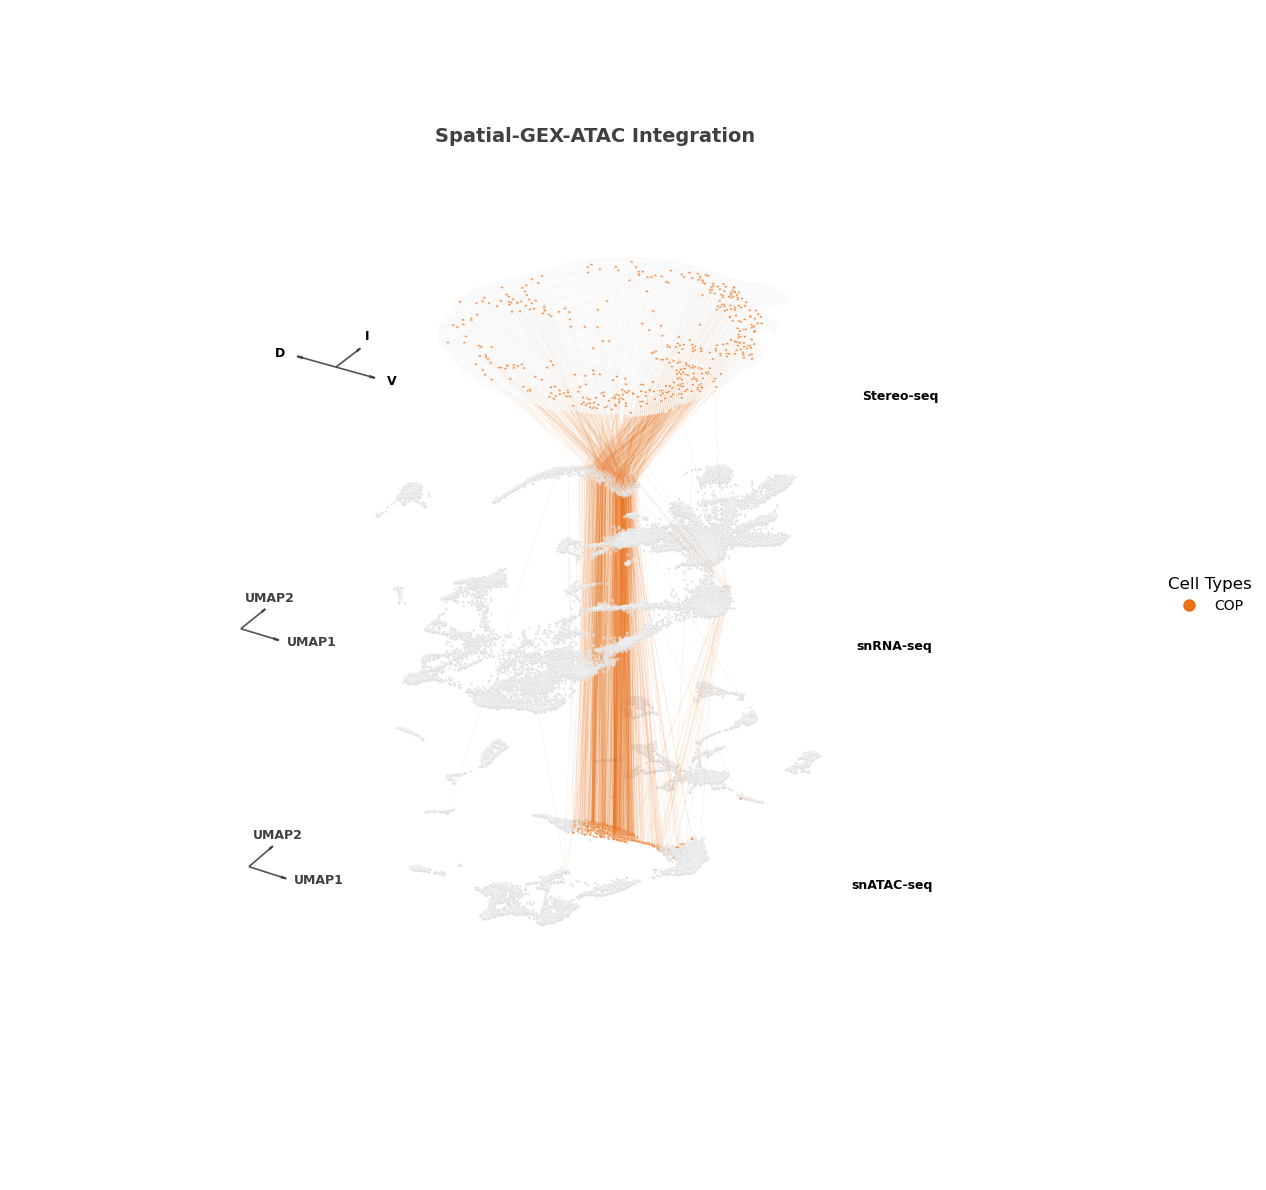

In [14]:
# Define a custom color map and target cell types; make sure the color codes are valid in Python
color_map = {
    # Neuronal lineages (purple/red dual gradient)
    'di3/5-1': '#7A0177',    # Dark color for the main di3/5 lineage
    'di3/5-2': '#AE017E',
    'di3/5-3': '#DD3497',
    'di4/6-1': '#67000D',    # Dark color for the main di4/6 lineage
    'di4/6-2': '#CB181D',
    'di4/6-3': '#EF3B2C',
    'di2?': '#D4B9DA',       # Uncertain subtype
    
    # Motor neurons (deep purple scale)
    'MN': '#54278F',         # Merged motor neuron class
    
    # Neural progenitor cells (green scale)
    'NPC_proliferative': '#238B45',
    'dp3-6_switched?': '#BAE4B3',
    
    # Glial lineage (blue/orange)
    'OPC': '#FE9929',        # Standard OPC color
    'OPC_proliferative': '#FEC44F',
    'COP': '#EC7014',        # More mature oligodendrocyte precursor state
    'MFOL/MOL': '#CC4C02',   # Myelinating cells
    'APC-1': '#08519C',      # Astrocyte precursor gradient
    'APC-2': '#3182BD',
    'APC-3': '#6BAED6',
    'FP/Ependymal': '#4292C6', # Special merged marker class
    
    # Peripheral neural cells
    'Schwann': '#8C6BB1',    # Schwann cells
    'PC': '#8C96C6',         # Pericytes
    
    # Vascular/peripheral cells
    'EC/doublet': '#3690C0', # Endothelial cells / doublets
    'VLMC': '#74C476',       # Vascular smooth muscle-like cells
    
    # Neural tube patterning (blue-purple scale)
    'v0/v1/v2a/v3': '#6A51A3', # Composite pattern class
    'v2b': '#807DBA',        # Subtype distinction
    'RP': '#9E9AC8',         # Roof plate
    
    # Immune cells
    'Microgila': '#C51B7D',  # Microglia (spelling retained from source annotation)
    
    # Quality control
    'lowq': '#F0F0F0',      # Low-quality cells
    
    # Unclassified
    'unknow1': '#BDBDBD',
    'unknow2': '#D9D9D9'
}



target_subtypes = ['COP']

# Call the visualization function
fig = visualization_3d(
    rna_umap=rna_umap,
    rna_anno=rna_anno,
    spatial_coord=spatial_coord,
    link_st_matrix=link_st_matrix,
    link_atac_matrix=link_atac_matrix,
    atac_umap=atac_umap,
    line_alpha=0.1,
    spatial_rot=150,  # Adjust the spatial rotation angle; this is an important parameter
    point_sizes={ 'rna': 3,'atac': 3,'spatial': 0.5 },
    scale_spot=10,
    color_map=color_map,
    target_subtypes=target_subtypes
)
fig

In [20]:
color_map

{'APC/pMN': '#4292C6',
 'multipotential_v': 'grey',
 'NPC_proliferative': '#006400',
 'EC': '#A6D7E7',
 'Meninges-2': '#5C816E',
 'multipotential_NPC': 'grey',
 'Meninges-1': '#7DBC8C',
 'Microglia': '#5C816E',
 'di1': '#9ECAE1',
 'di4/6': '#67000d',
 'v2b-1': '#694d9f',
 'APC_p0/1_progenitor': '#6BAED6',
 'v1-2': '#9b95c9',
 'v1-1': '#7d5886',
 'v2b-2': '#8A6FAF',
 'di6': '#224b8f',
 'unknow1': 'grey',
 'RP': '#4B4B4B',
 'MN-2': '#6f60aa',
 'MN-3': '#6950a1',
 'FP/Ependymal': '#252525',
 'PC': '#BAD58F',
 'dp1/2': '#C6DBEF',
 'dp3-6': '#BB92D0',
 'blood': '#E24546',
 'multipotential_p0/1': '#D3D3D3',
 'v0': '#9b95c9',
 'MN-1': '#6950a1',
 'Meninges-3': '#5C816E',
 'unknow2': 'grey',
 'v3': '#7d5886',
 'multipotential_dp3-6': '#BB92D0',
 'di3/5': '#AE017E',
 'MN-4': '#8884C2',
 'v2a': '#6f60aa'}

In [15]:
# Handle cell-type names that require filename sanitization

def sanitize_filename(name):
    return name.replace("/", "_").replace("?", "").replace(" ", "_")

# Iterate over all cell types in the color map
for celltype in color_map.keys():

    # Set the current target subtype
    target_subtypes = [celltype]
    
    # Generate the figure
    fig = visualization_3d(
        rna_umap=rna_umap,
        rna_anno=rna_anno,
        spatial_coord=spatial_coord,
        link_st_matrix=link_st_matrix,
        link_atac_matrix=link_atac_matrix,
        atac_umap=atac_umap,
        line_alpha=0.1,
        spatial_rot=150,  # Adjust the spatial rotation angle; this is an important parameter
        point_sizes={ 'rna': 3,'atac': 3,'spatial': 0.5 },
        scale_spot=10,
        color_map=color_map,
        target_subtypes=target_subtypes
    )
    
    # Save the figure
    safe_name = sanitize_filename(celltype)
    fig.savefig(
        f"./plot/{safe_name}_3dplot.png",  # Save using a safe filename
        dpi=300,
        bbox_inches="tight",
        facecolor="white"  # Set a white background
    )

    print(f"Saved: {safe_name}_3dplot.png")

Saved: di3_5-1_3dplot.png
Saved: di3_5-2_3dplot.png
Saved: di3_5-3_3dplot.png
Saved: di4_6-1_3dplot.png
Saved: di4_6-2_3dplot.png
Saved: di4_6-3_3dplot.png
Saved: di2_3dplot.png
Saved: MN_3dplot.png
Saved: NPC_proliferative_3dplot.png
Saved: dp3-6_switched_3dplot.png
Saved: OPC_3dplot.png
Saved: OPC_proliferative_3dplot.png
Saved: COP_3dplot.png
Saved: MFOL_MOL_3dplot.png
Saved: APC-1_3dplot.png
Saved: APC-2_3dplot.png
Saved: APC-3_3dplot.png
Saved: FP_Ependymal_3dplot.png
Saved: Schwann_3dplot.png
Saved: PC_3dplot.png
Saved: EC_doublet_3dplot.png
Saved: VLMC_3dplot.png
Saved: v0_v1_v2a_v3_3dplot.png
Saved: v2b_3dplot.png
Saved: RP_3dplot.png
Saved: Microgila_3dplot.png
Saved: lowq_3dplot.png
Saved: unknow1_3dplot.png
Saved: unknow2_3dplot.png
